In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import dataloader as dl
import torch.optim as SGD
import numpy as np

Softmax Regression

In [2]:
class Softmax_Regression_from_scratch():
    def __init__(self, input_size, num_classes):
        self.w = nn.Parameter(torch.randn(input_size, num_classes) * 0.01, requires_grad=True)
        self.b = torch.zeros(num_classes, requires_grad=True)



        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []

    def softmax(self, z):
        exp_z = torch.exp(z)
        return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

    def cross_entropy_loss(self, y_true_indices, y_pred_softmax):
        num_samples = y_true_indices.shape[0]
        correct_class_probs = y_pred_softmax[range(num_samples), y_true_indices]
        epsilon = 1e-9
        loss = -torch.log(correct_class_probs + epsilon)
        return torch.mean(loss)

    def forward_pass(self, x):
        logits = x @ self.w + self.b
        y_pred_softmax = self.softmax(logits)
        return y_pred_softmax


    def train(self, learning_rate, no_epochs, train_loader, val_loader):
        ## training phase
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0
            for data, target in train_loader:

                y_pred = self.forward_pass(data)
                loss = self.cross_entropy_loss(target, y_pred)

                train_accuracy += self.calculate_accuracy(target, y_pred)
                train_loss += loss.item()

                loss.backward()

                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b -= learning_rate * self.b.grad

                    self.w.grad.zero_()
                    self.b.grad.zero_()

            ## Validation Phase
            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_pred = self.forward_pass(val_data)

                    val_accuracy += self.calculate_accuracy(val_target, val_pred)
                    val_loss = self.cross_entropy_loss(val_target, val_pred)

                    val_losses += val_loss.item()

            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)

            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)

            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f}   | Val Acc: {self.validation_accuracies[epoch]:.2f}%')

    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = torch.argmax(y_pred, dim=1)
        return predicted_labels

    def calculate_accuracy(self, y_true_indices, y_pred_softmax):
        predicted_labels = torch.argmax(y_pred_softmax, dim=1)
        correct = (predicted_labels == y_true_indices).sum().item()
        return (correct / y_true_indices.shape[0]) * 100

Configuration

In [3]:
Learning_rate = 0.01
no_epochs = 30
input_size = 28 * 28
num_classes = 10

Training the model

In [4]:
model = Softmax_Regression_from_scratch(input_size, num_classes)
loader=dl.build_loader(64)
model.train(Learning_rate, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.1698 | Train Acc: 78.77%
  Val Loss: 0.7651   | Val Acc: 83.60%
Epoch 2/30
  Train Loss: 0.6557 | Train Acc: 85.46%
  Val Loss: 0.5889   | Val Acc: 85.75%
Epoch 3/30
  Train Loss: 0.5445 | Train A

Training vs Validation loss

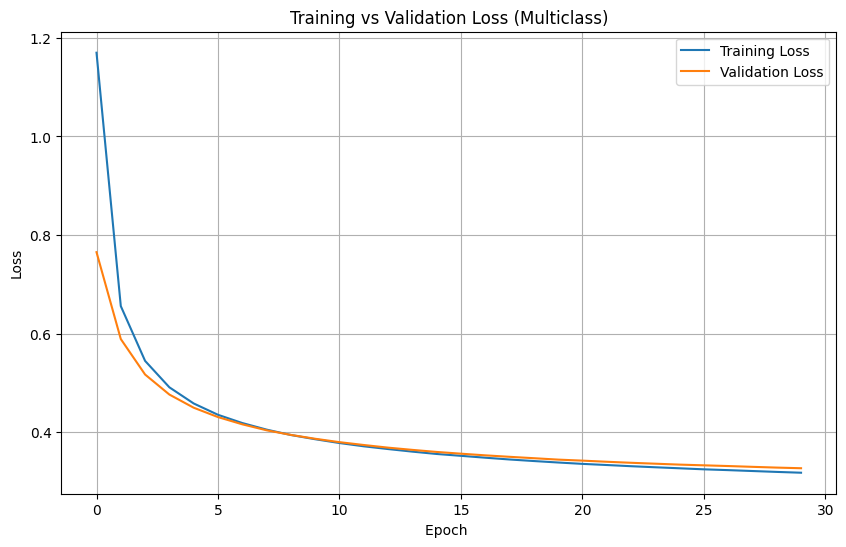

In [5]:

def plot_loss(text):
    plt.figure(figsize=(10, 6))
    plt.plot(model.training_losses, label='Training Loss')
    plt.plot(model.validation_losses, label='Validation Loss')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss (Multiclass)')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_loss('')

Test vs validation accuracy

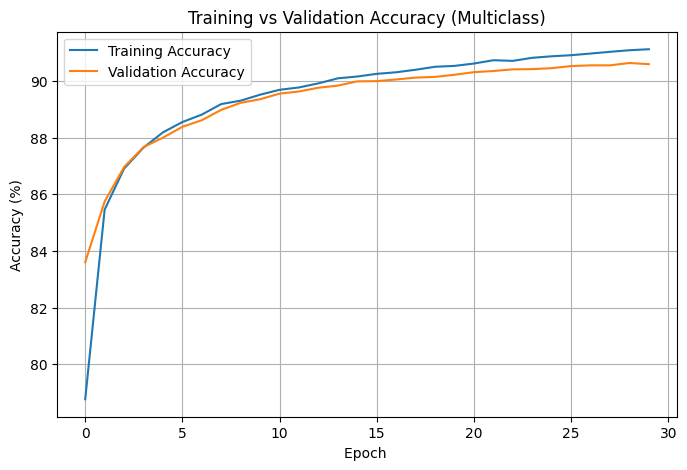

In [6]:

def plot_acc(text):
    plt.figure(figsize=(8, 5))
    plt.plot(model.training_accuracies, label='Training Accuracy')
    plt.plot(model.validation_accuracies, label='Validation Accuracy')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Validation Accuracy (Multiclass)')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_acc('')

### Learning curve with error bars

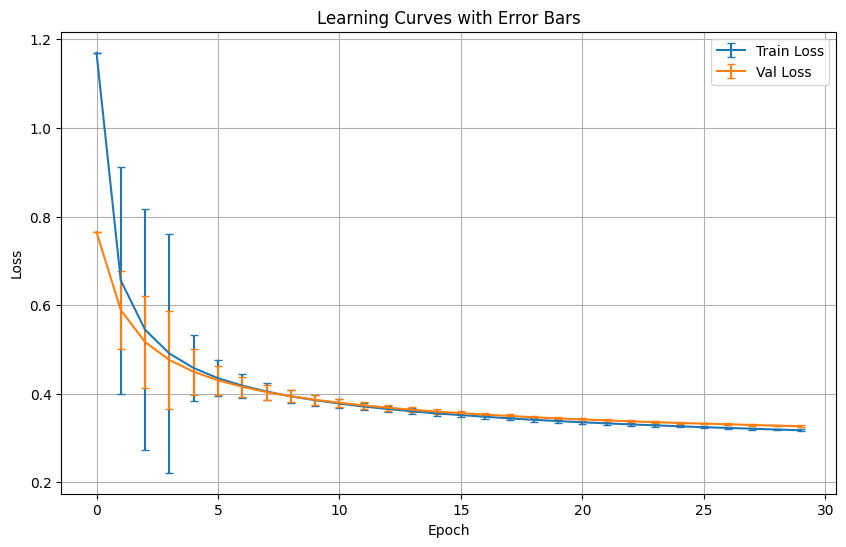

In [7]:
window = 3
train_std = [np.std(model.training_losses[max(0,i-window):i+1]) for i in range(len(model.training_losses))]
val_std = [np.std(model.validation_losses[max(0,i-window):i+1]) for i in range(len(model.validation_losses))]

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(model.training_losses)), model.training_losses, yerr=train_std, label='Train Loss', capsize=3)
plt.errorbar(range(len(model.validation_losses)), model.validation_losses, yerr=val_std, label='Val Loss', capsize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.grid(True)
plt.show()

### converge Analysis

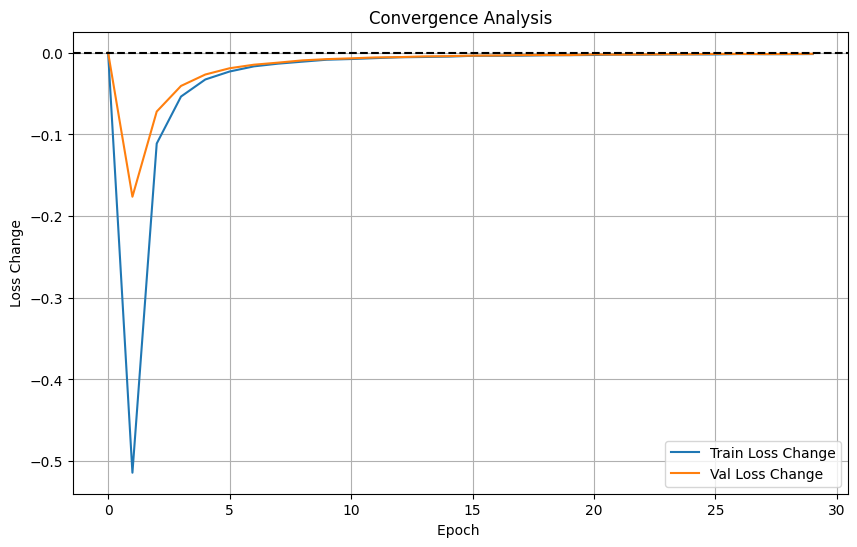

In [8]:
def plot_converge(text):
    train_change = [0] + [model.training_losses[i] - model.training_losses[i-1] for i in range(1, len(model.training_losses))]
    val_change = [0] + [model.validation_losses[i] - model.validation_losses[i-1] for i in range(1, len(model.validation_losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(train_change, label='Train Loss Change')
    plt.plot(val_change, label='Val Loss Change')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss Change')
    plt.title('Convergence Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_converge('')

test set evaluation and confusion matrix

In [ ]:
def test_model():
  print("\n--- Evaluating on Test Set ---")
  accuracy = 0
  all_targets = []
  all_predictions = []

  with torch.no_grad():
      for data, target in loader['test_loader_linear']:
          prediction = model.predict(data) 
          correct = (prediction == target).sum().item()
          total = target.shape[0]
          accuracy += (correct / total) * 100
          all_targets.extend(target.numpy())
          all_predictions.extend(prediction.numpy())

  test_accuracy = accuracy / len(loader['test_loader_linear'])
  print(f'Average Test Accuracy over all batches: {test_accuracy:.2f}%')
  matrix = confusion_matrix(np.array(all_targets), np.array(all_predictions))
  print("\nConfusion Matrix:")
  print(matrix)
  class_accuracy = matrix.diagonal() / matrix.sum(axis=1)
  print("\nPer Class Accuracy:")
  for i, acc in enumerate(class_accuracy):
      print(f'Accuracy for digit {i}: {acc * 100:.2f}%')
test_model()


--- Evaluating on Test Set ---
Average Test Accuracy over all batches: 90.95%

Confusion Matrix:
[[1137    0    5    1    1   11   11    1   13    5]
 [   0 1293   10   11    1   11    1    3   17    2]
 [  10   10 1036   18   30    7   14   20   35   11]
 [   6    7   35 1068    1   39    8   21   28   13]
 [   0    6    7    1 1080    1    3    1    4   65]
 [  14   13    8   37    9  944   18    4   29    8]
 [  10    6    6    0    6   23 1123    1    9    0]
 [   8   12   15    6   10    1    0 1153    5   43]
 [   4   28    9   26    8   36   10    9 1023   17]
 [  11    8    6   22   30   11    2   37    7 1056]]

Per Class Accuracy:
Accuracy for digit 0: 95.95%
Accuracy for digit 1: 95.85%
Accuracy for digit 2: 86.99%
Accuracy for digit 3: 87.11%
Accuracy for digit 4: 92.47%
Accuracy for digit 5: 87.08%
Accuracy for digit 6: 94.85%
Accuracy for digit 7: 92.02%
Accuracy for digit 8: 87.44%
Accuracy for digit 9: 88.74%


# Built-in implementaion of Softmax Regression

In [10]:
class SoftmaxRegressionTorch(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
    def forward(self, x):
        return self.linear(x)

torch_model = SoftmaxRegressionTorch(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = SGD.SGD(torch_model.parameters(), lr=Learning_rate)

for epoch in range(no_epochs):
    for data, target in loader['train_loader_linear']:
        optimizer.zero_grad()
        output = torch_model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()


In [11]:
accuracy_list = []
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in loader['test_loader_linear']:
        images = images.reshape(-1, input_size)
        outputs = torch_model(images)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = Softmax_Regression_from_scratch.calculate_accuracy(None, labels, torch.softmax(outputs, dim=1))
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        accuracy_list.append(accuracy)

    avg_accuracy = sum(accuracy_list) / len(accuracy_list)

    print(f'Accuracy of the model on the test images: {avg_accuracy}%')

Accuracy of the model on the test images: 90.81615691489361%


### defining hyper parameters

In [12]:
learning_rates = [0.001,0.01,0.1,1]
batch_sizes = [16,32,64,128]

Testing different learning rates with fixed batch size (64):
Training with Learning Rate: 0.001, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 2.0380 | Train Acc: 60.52%
  Val Loss: 1.8130   | Val Acc: 74.03%
Epoch 2/30
  Train L

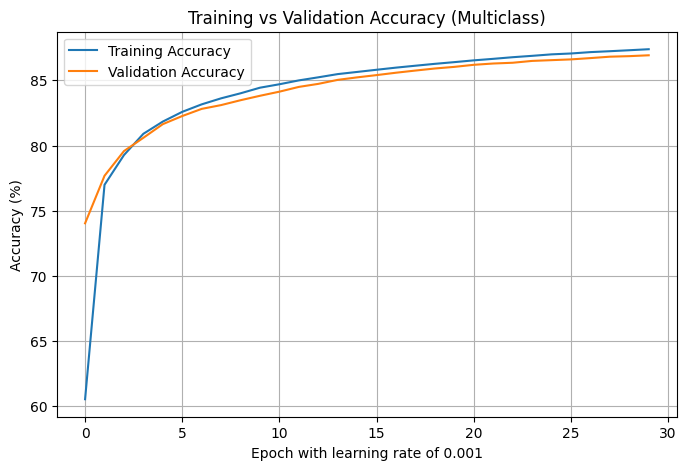

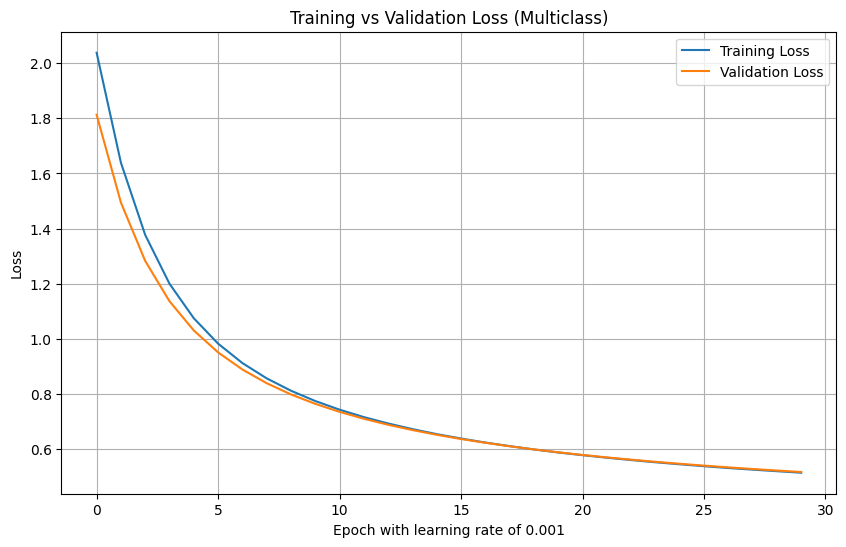

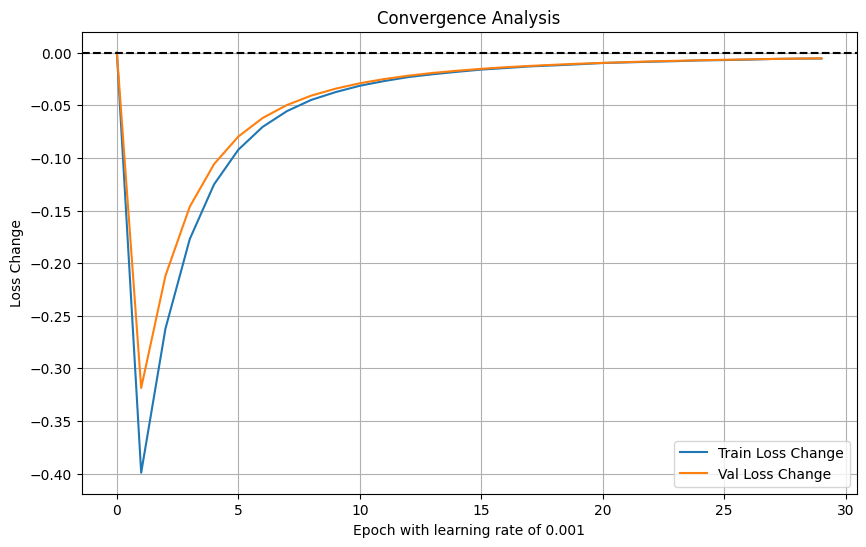

Training with Learning Rate: 0.01, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.1720 | Train Acc: 78.56%
  Val Loss: 0.7662   | Val Acc: 83.62%
Epoch 2/30
  Train Loss: 0.6567 | Train Acc: 85.46%
  Val Loss: 0.5893   | Val Acc

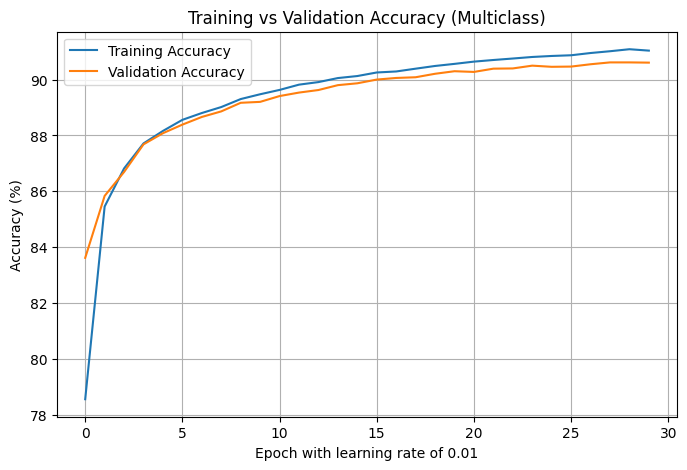

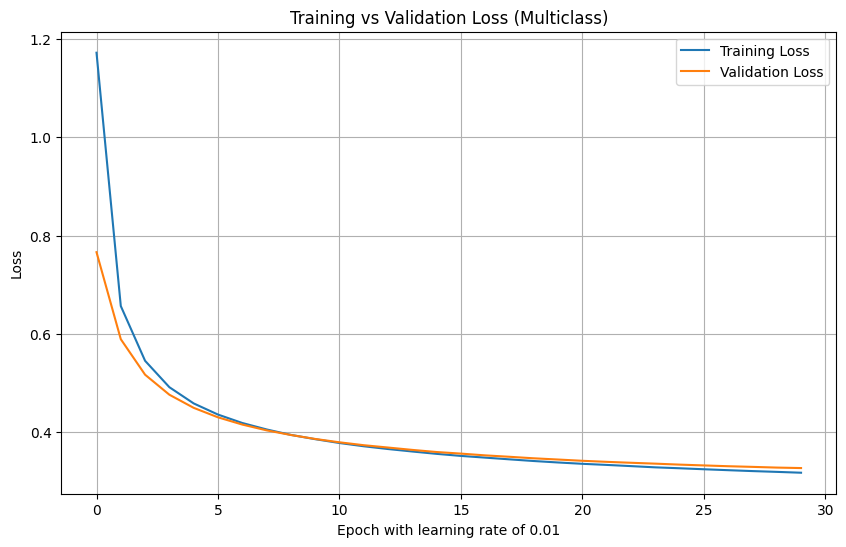

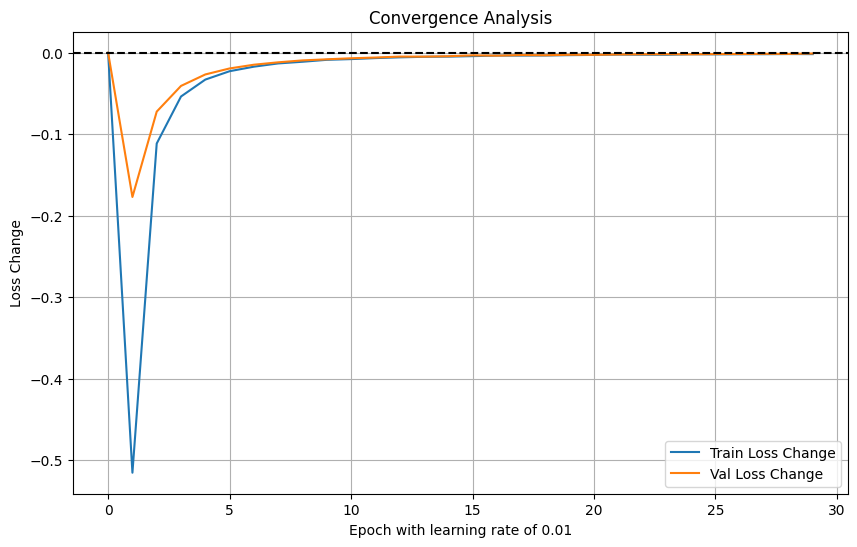

Training with Learning Rate: 0.1, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.5442 | Train Acc: 86.32%
  Val Loss: 0.3879   | Val Acc: 89.12%
Epoch 2/30
  Train Loss: 0.3612 | Train Acc: 89.92%
  Val Loss: 0.3471   | Val Acc:

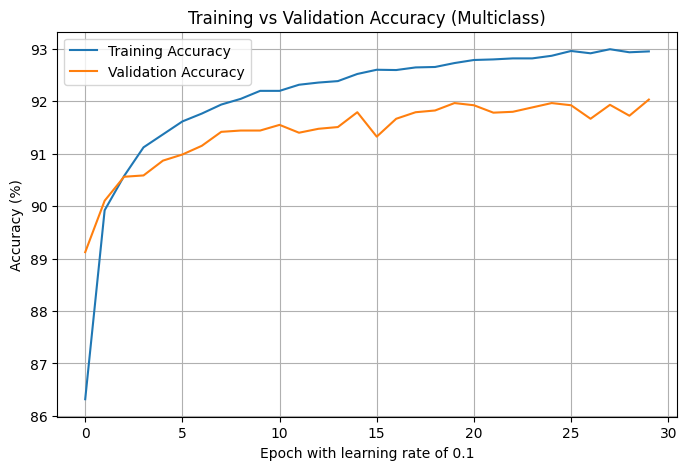

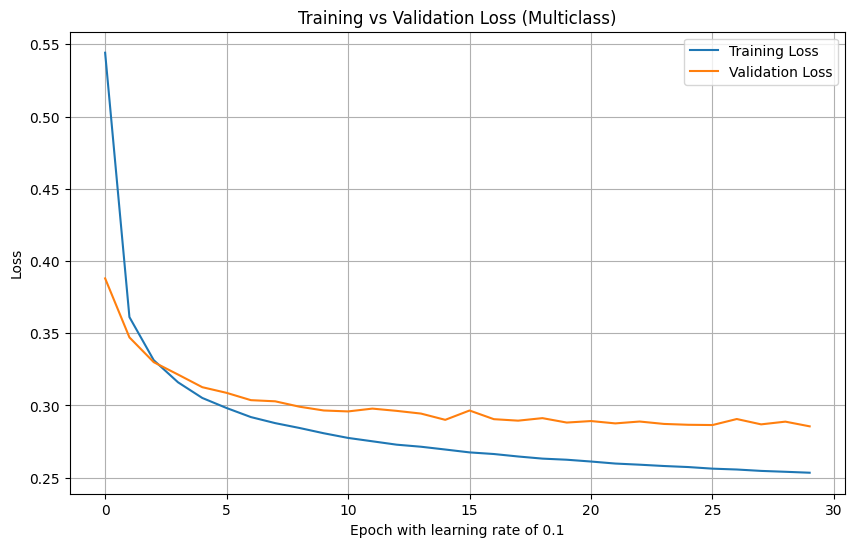

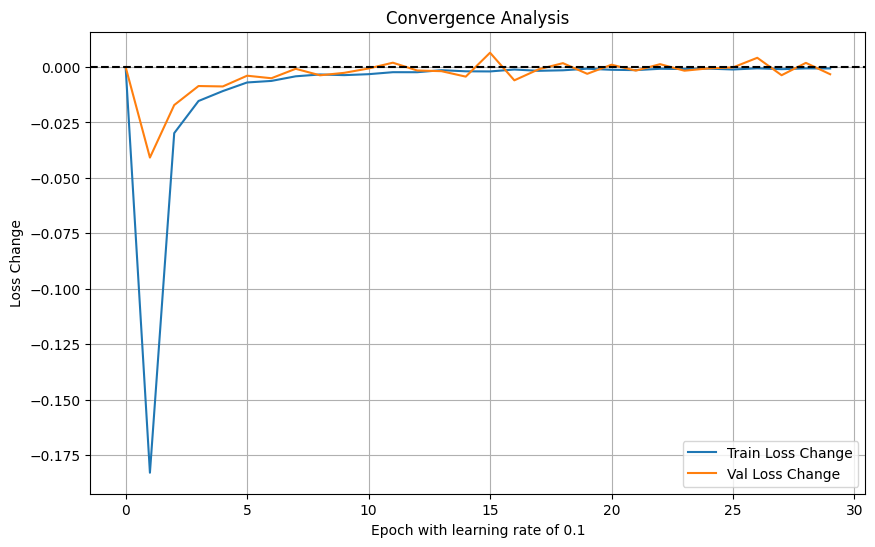

Training with Learning Rate: 1, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.4566 | Train Acc: 87.06%
  Val Loss: 0.3528   | Val Acc: 89.94%
Epoch 2/30
  Train Loss: 0.3346 | Train Acc: 90.34%
  Val Loss: 0.3332   | Val Acc: 9

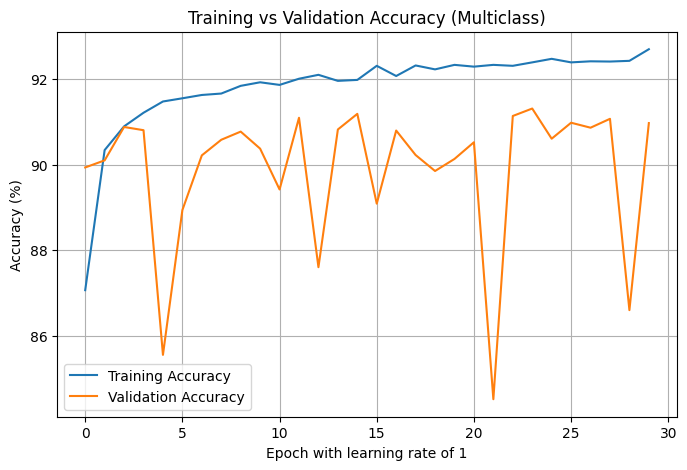

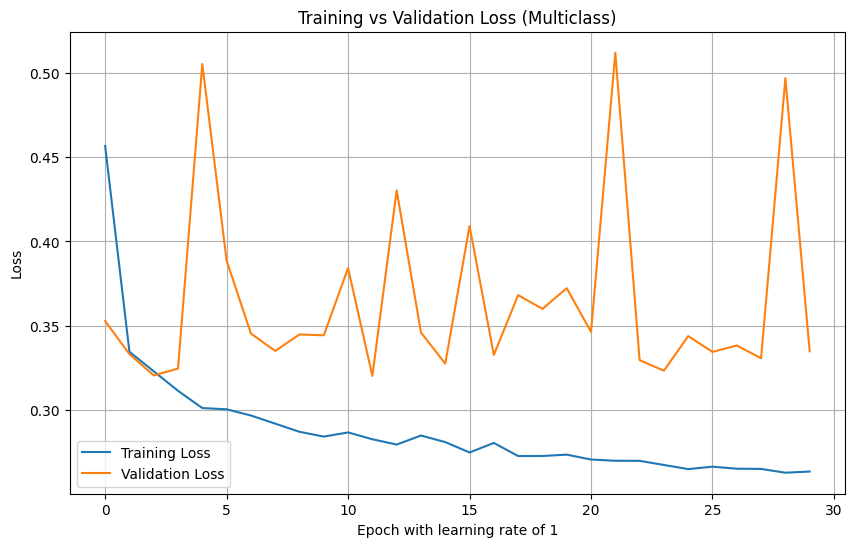

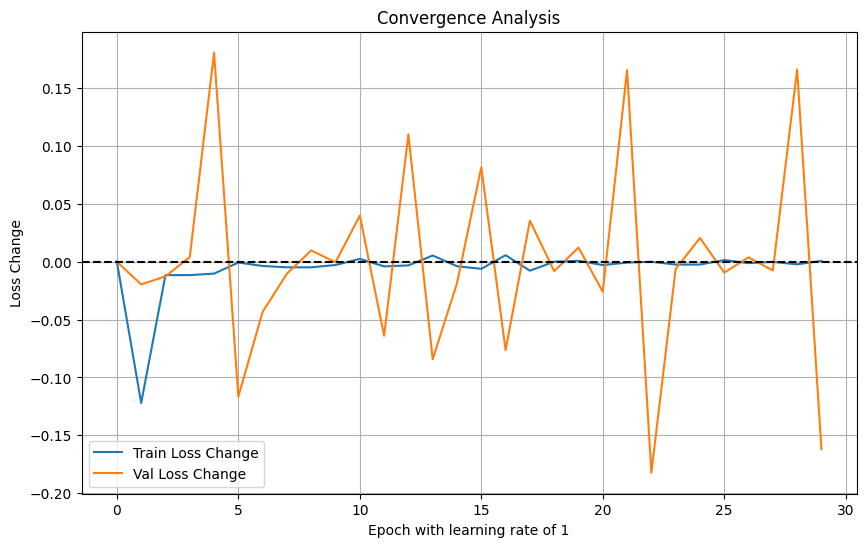

In [13]:
results_lr = []
fixed_batch_size = 64
print("Testing different learning rates with fixed batch size (64):")
best_val_accuracy_lr = 0
best_lr=None

for lr in learning_rates:
    print(f"Training with Learning Rate: {lr}, Batch Size: {fixed_batch_size}")

    model = Softmax_Regression_from_scratch(input_size, num_classes)
    loader = dl.build_loader(fixed_batch_size)

    model.train(lr, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])
    plot_acc(f'with learning rate of {lr}')
    plot_loss(f'with learning rate of {lr}')
    plot_converge(f'with learning rate of {lr}')

    current_best_val_accuracy = max(model.validation_accuracies)
    if current_best_val_accuracy > best_val_accuracy_lr:
        best_val_accuracy_lr = current_best_val_accuracy
        best_lr=lr

getting test accuracy for the best learning rate

In [14]:
print(f"the best learning rate {best_lr}")
model = Softmax_Regression_from_scratch(input_size, num_classes)
loader = dl.build_loader(fixed_batch_size)
model.train(best_lr, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])
test_model()

the best learning rate 0.1
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.5448 | Train Acc: 86.50%
  Val Loss: 0.3891   | Val Acc: 89.08%
Epoch 2/30
  Train Loss: 0.3615 | Train Acc: 90.03%
  Val Loss: 0.3451   | Val Acc: 90.42%
Epoch 3/30
  T

### getting the best batch size


Testing different batch sizes with fixed learning rate (0.01):
Training with Learning Rate: 0.01, Batch Size: 16
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.7180 | Train Acc: 84.28%
  Val Loss: 0.4766   | Val Acc: 87.46%
Epoch 2/30
  Train

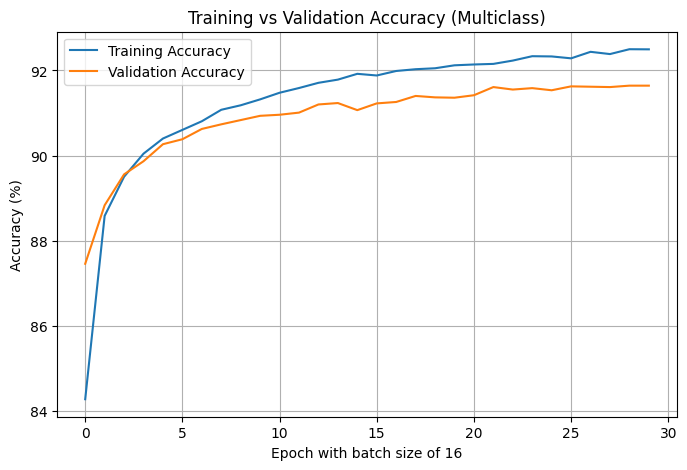

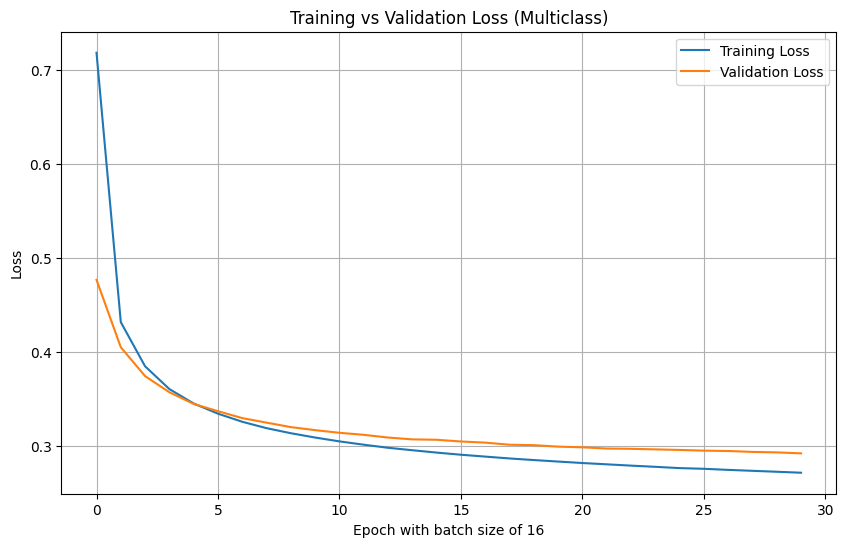

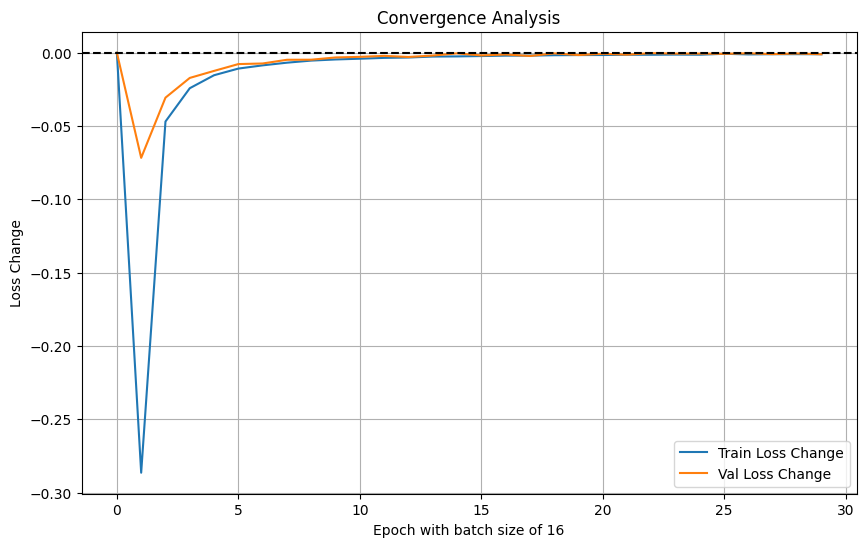

Training with Learning Rate: 0.01, Batch Size: 32
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.9121 | Train Acc: 81.78%
  Val Loss: 0.5892   | Val Acc: 86.08%
Epoch 2/30
  Train Loss: 0.5190 | Train Acc: 87.19%
  Val Loss: 0.4770   | Val Acc

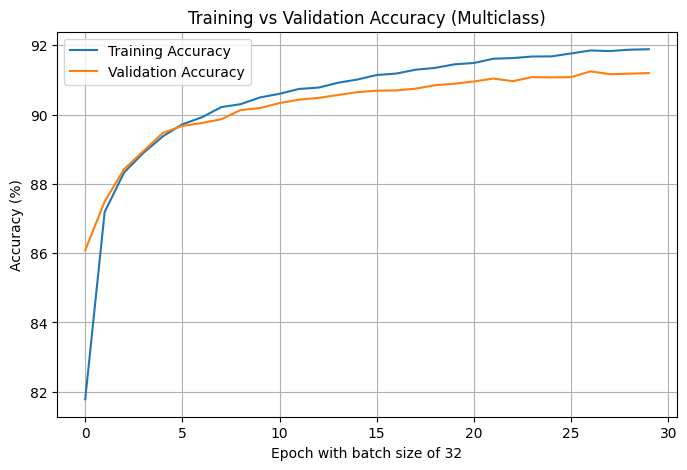

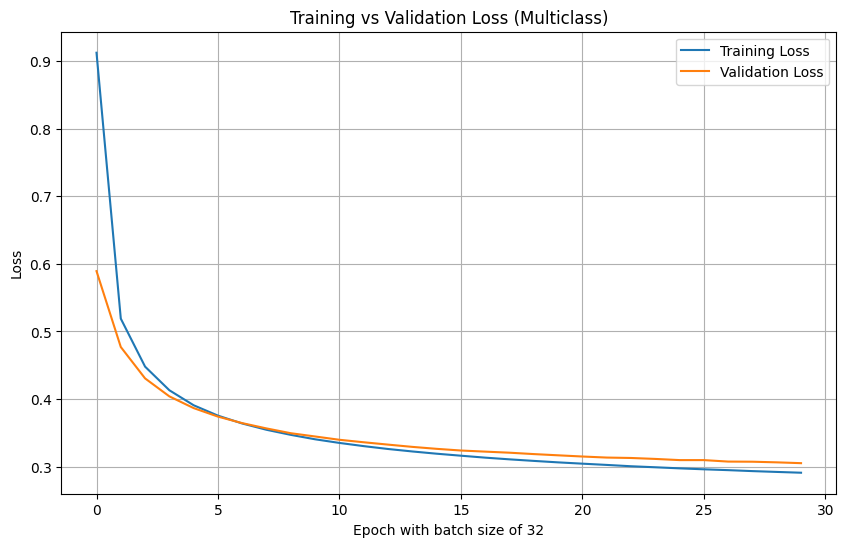

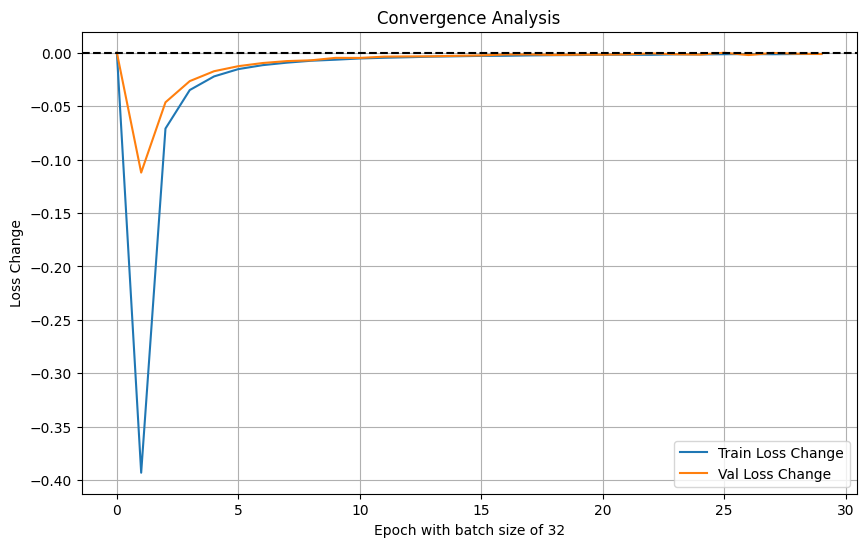

Training with Learning Rate: 0.01, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.1709 | Train Acc: 78.92%
  Val Loss: 0.7664   | Val Acc: 83.64%
Epoch 2/30
  Train Loss: 0.6563 | Train Acc: 85.43%
  Val Loss: 0.5896   | Val Acc

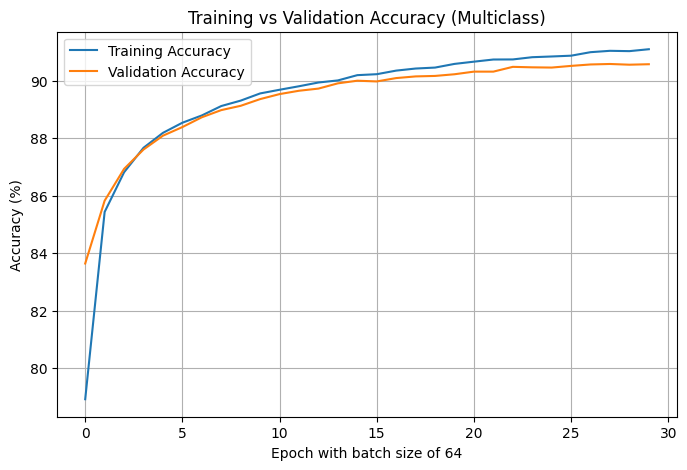

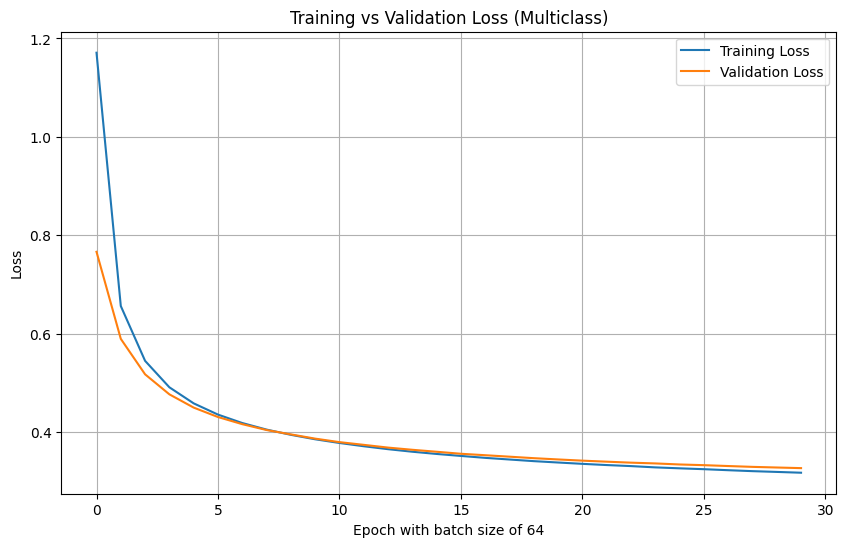

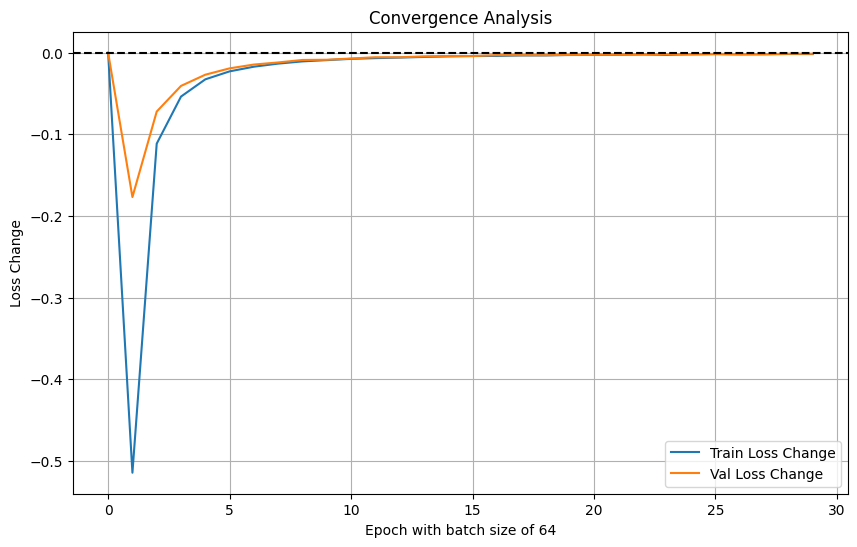

Training with Learning Rate: 0.01, Batch Size: 128
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.4740 | Train Acc: 74.11%
  Val Loss: 1.0321   | Val Acc: 81.04%
Epoch 2/30
  Train Loss: 0.8708 | Train Acc: 83.26%
  Val Loss: 0.7645   | Val Ac

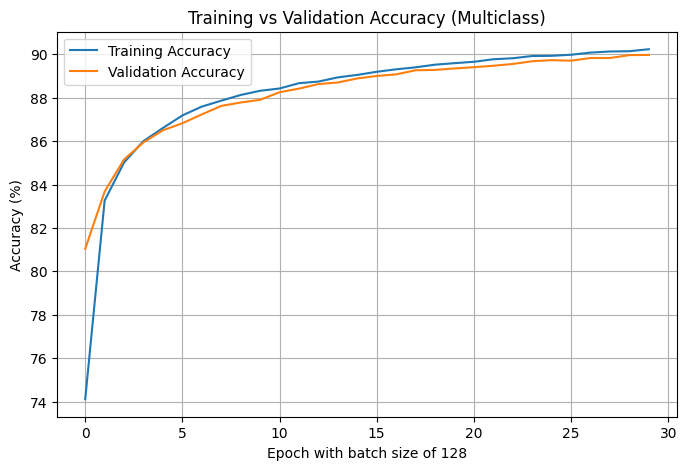

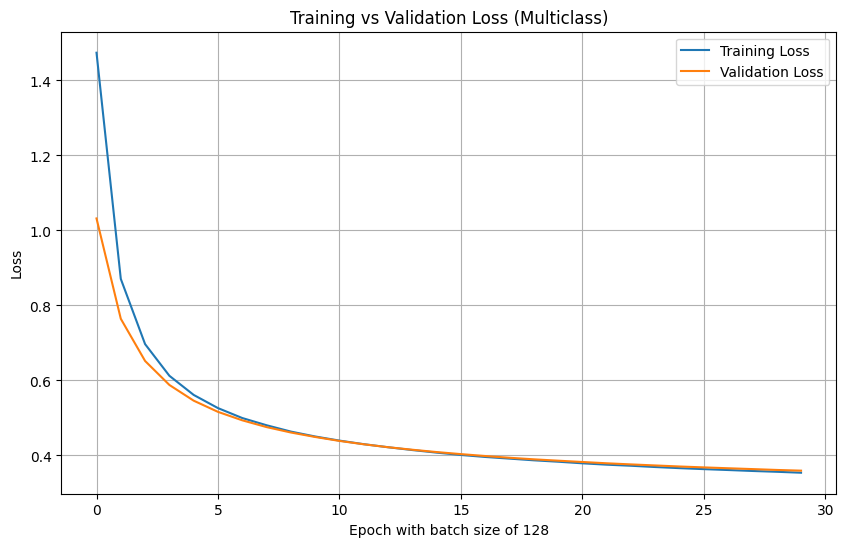

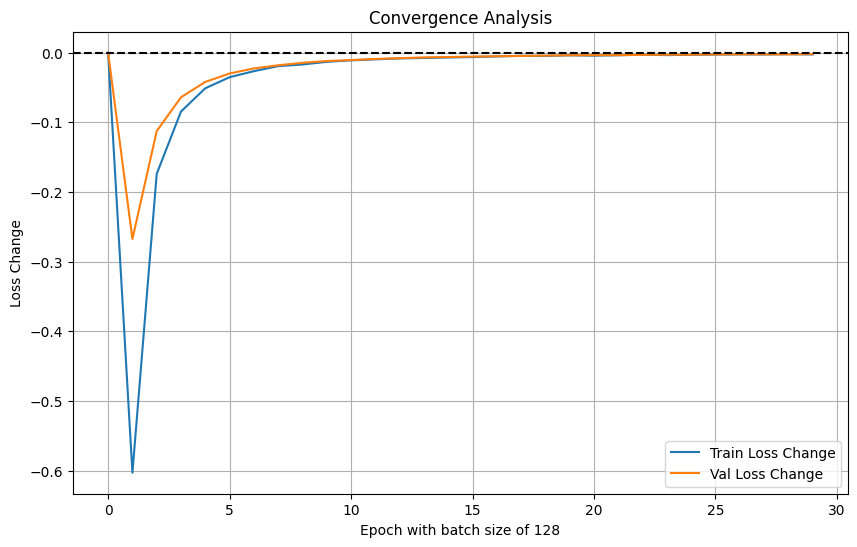

In [15]:
results_bs = []
fixed_learning_rate = 0.01

print("\nTesting different batch sizes with fixed learning rate (0.01):")
best_val_accuracy_bs = 0
best_bs=None

for bs in batch_sizes:
    print(f"Training with Learning Rate: {fixed_learning_rate}, Batch Size: {bs}")

    model = Softmax_Regression_from_scratch(input_size, num_classes)
    loader = dl.build_loader(bs)

    model.train(fixed_learning_rate, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])
    plot_acc(f'with batch size of {bs}')
    plot_loss(f'with batch size of {bs}')
    plot_converge(f'with batch size of {bs}')
    current_best_val_accuracy = max(model.validation_accuracies)

    if current_best_val_accuracy > best_val_accuracy_bs:
        best_val_accuracy_bs = current_best_val_accuracy
        best_bs=bs

### calcualting the test accuracy for best batch size

In [16]:
print(f"the best batch size {best_bs}")

model = Softmax_Regression_from_scratch(input_size, num_classes)
loader = dl.build_loader(best_bs)
model.train(fixed_learning_rate, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])
test_model()

the best batch size 16
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.7175 | Train Acc: 84.48%
  Val Loss: 0.4766   | Val Acc: 87.37%
Epoch 2/30
  Train Loss: 0.4311 | Train Acc: 88.58%
  Val Loss: 0.4044   | Val Acc: 88.90%
Epoch 3/30
  Train

### combining the best learning rate with best batch size

In [17]:
import time
print(f"the best batch size {best_bs}")
print(f"the best learning rate {best_lr}")
model = Softmax_Regression_from_scratch(input_size, num_classes)
loader = dl.build_loader(best_bs)

start_time = time.time()
model.train(best_lr, no_epochs, loader['train_loader_linear'], loader['val_loader_linear'])
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

test_model()

the best batch size 16
the best learning rate 0.1
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.4066 | Train Acc: 88.49%
  Val Loss: 0.3197   | Val Acc: 90.53%
Epoch 2/30
  Train Loss: 0.3124 | Train Acc: 90.99%
  Val Loss: 0.3091   | Val Acc